Fold,Method,Metric label,0,1,2,3,4
0,unitvelo_uni,CBDir,0.681698,0.695559,0.717279,0.686768,-0.045977
1,unitvelo_uni,ICVCoh,0.956337,0.956568,0.950419,0.930134,0.879895
2,unitvelo_uni,CTO,0.703955,0.692870,0.700738,0.688758,0.685580
3,unitvelo_uni,STS,0.850813,0.837391,0.814249,0.802130,0.805290
4,pyrovelocity_m2,CBDir,0.643125,0.666406,0.683353,0.677831,NaN
5,pyrovelocity_m2,ICVCoh,0.905010,0.900162,0.893397,0.866109,NaN
6,pyrovelocity_m2,CTO,0.694335,0.677308,0.690046,0.694527,NaN
7,pyrovelocity_m2,STS,0.799112,0.798047,0.797455,0.797437,NaN
8,velovi,CBDir,0.682927,0.684603,0.707913,0.707062,0.703976
9,velovi,ICVCoh,0.914719,0.921346,0.944154,0.942179,0.949258


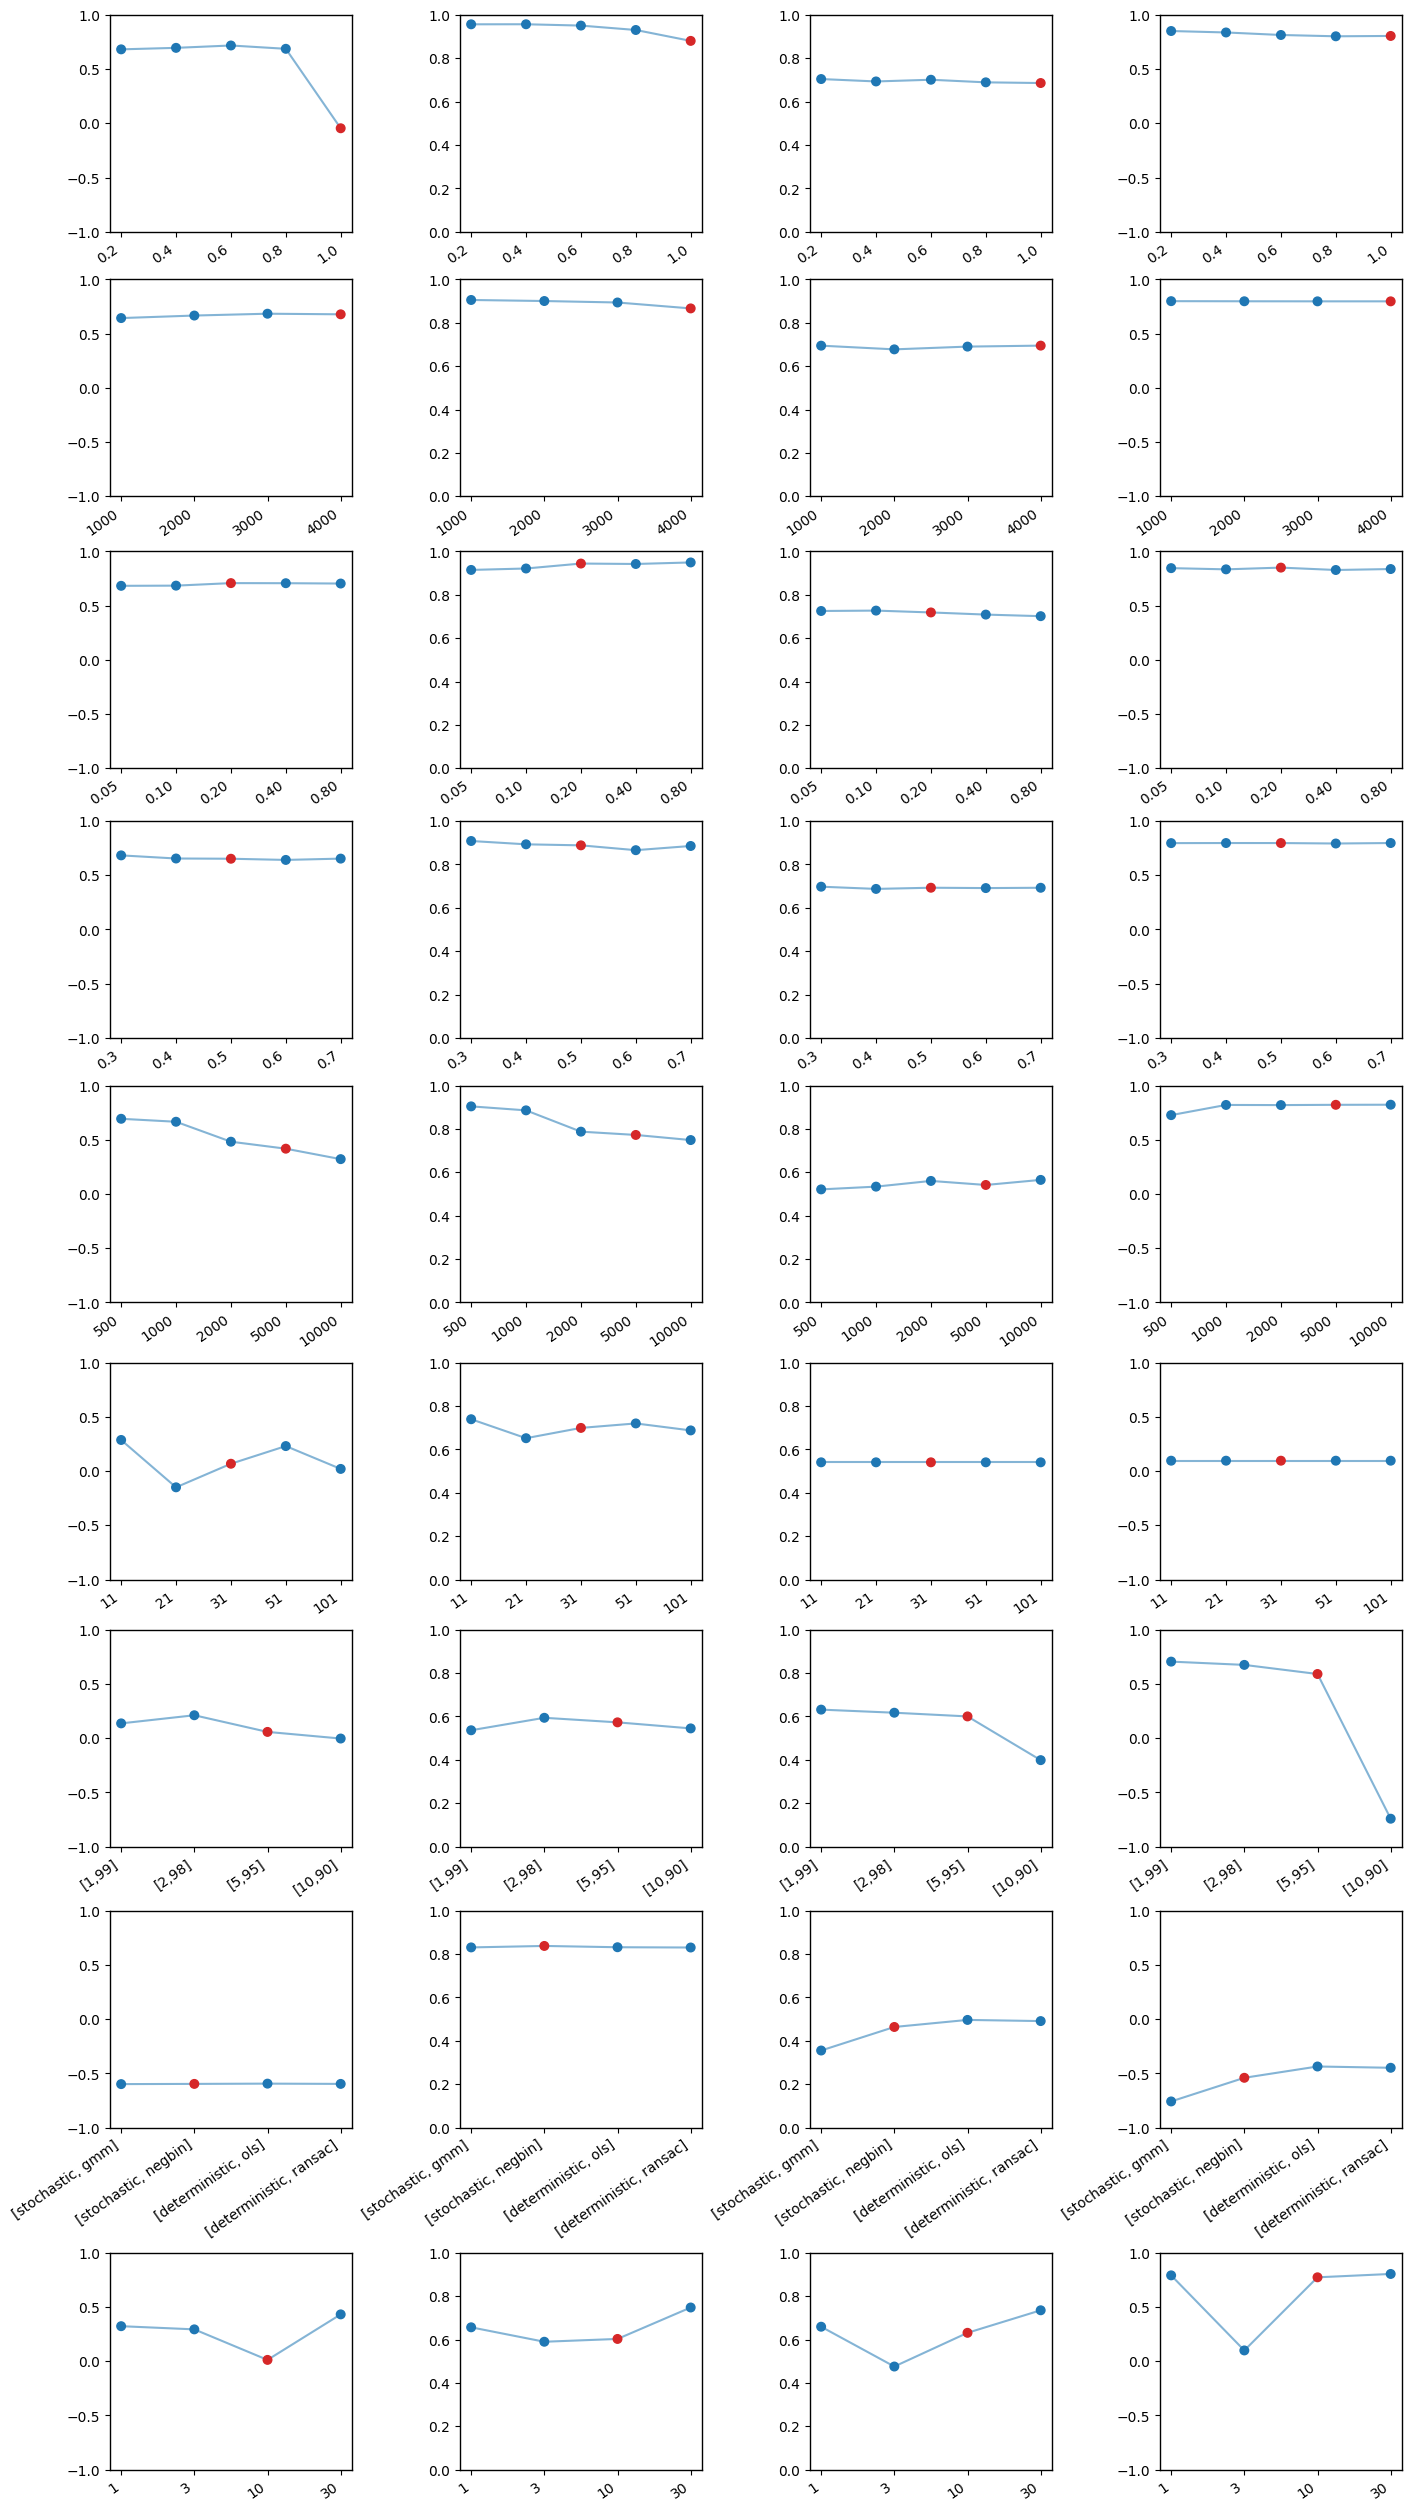

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd


DATA_DIR_CANDIDATES = [
    Path("evaluation_hyper"),
    Path("revision/hyper/evaluation_hyper"),
]
DATA_DIR = next((path for path in DATA_DIR_CANDIDATES if path.exists()), None)
if DATA_DIR is None:
    raise FileNotFoundError("Cannot find evaluation_hyper directory.")

METRIC_LABELS = {
    "cbdir": "CBDir",
    "icvcoh": "ICVCoh",
    "cto": "CTO",
    "spearman": "STS",
}
METHOD_ORDER = ["unitvelo_uni", "pyrovelocity_m2", "velovi", "sctour_zinb", "sdevelo",
                "deepvelo","velocyto","dynamo_m1","svelvetvae"]
METRIC_ORDER = ["cbdir", "icvcoh", "cto", "spearman"]
METRIC_YLIMS = {
    "cbdir": (-1, 1),
    "spearman": (-1, 1),
    "icvcoh": (0, 1),
    "cto": (0, 1),
}
DEFAULT_FOLDS = {
    "velovi": 2,
    "unitvelo_uni": 4,
    "sdevelo": 3,
    "sctour_zinb": 2,
    "pyrovelocity_m2": 3,
    "deepvelo": 2,
    "velocyto": 2,
    "dynamo_m1": 1,
    "svelvetvae":2
}
DEFAULT_COLOR = "#d62728"
OTHER_COLOR = "#1f77b4"

# Replace the text below with the meaning of each fold for each method.
# These labels will be shown on the X-axis of the corresponding method plots.
FOLD_LABELS = {
    "velovi": {
        0: "0.05",
        1: "0.10",
        2: "0.20",
        3: "0.40",
        4: "0.80",
    },
    "unitvelo_uni": {
        0: "0.2",
        1: "0.4",
        2: "0.6",
        3: "0.8",
        4: "1.0",
    },
    "sdevelo": {
        0: "500",
        1: "1000",
        2: "2000",
        3: "5000",
        4: "10000"
    },
    "sctour_zinb": {
        0: "0.3",
        1: "0.4",
        2: "0.5",
        3: "0.6",
        4: "0.7",
    },
    "pyrovelocity_m2": {
        0: "1000",
        1: "2000",
        2: "3000",
        3: "4000",
    },
    "deepvelo": {
        0: "11",
        1: "21",
        2: "31",
        3: "51",
        4: "101"
    },
    "velocyto": {
        0: "[1,99]",
        1: "[2,98]",
        2: "[5,95]",
        3: "[10,90]",
    },
    "dynamo_m1": {
        0: "[stochastic, gmm]",
        1: "[stochastic, negbin]",
        2: "[deterministic, ols]",
        3: "[deterministic, ransac]",
    },
    "svelvetvae": {
        0: "1",
        1: "3",
        2: "10",
        3: "30",
    },
}


records = []
for csv_path in sorted(DATA_DIR.glob("*_df_*.csv")):
    metric, method_from_file = csv_path.stem.split("_df_", maxsplit=1)
    df = pd.read_csv(csv_path)
    method = df.loc[0, "Method"] if "Method" in df.columns else method_from_file

    for fold_col in [col for col in df.columns if col != "Method"]:
        records.append(
            {
                "Method": method,
                "Metric": metric,
                "Metric label": METRIC_LABELS.get(metric, metric),
                "Fold": int(fold_col),
                "Score": pd.to_numeric(df.loc[0, fold_col], errors="coerce"),
            }
        )

scores = pd.DataFrame(records)
scores["Method"] = pd.Categorical(scores["Method"], categories=METHOD_ORDER, ordered=True)
scores["Metric"] = pd.Categorical(scores["Metric"], categories=METRIC_ORDER, ordered=True)
scores = scores.sort_values(["Method", "Metric", "Fold"]).reset_index(drop=True)

scores_wide = scores.pivot_table(
    index=["Method", "Metric label"],
    columns="Fold",
    values="Score",
    aggfunc="first",
    observed=False,
).reset_index()

metric_label_order = [METRIC_LABELS[metric] for metric in METRIC_ORDER]
scores_wide["Metric label"] = pd.Categorical(
    scores_wide["Metric label"], categories=metric_label_order, ordered=True
)
scores_wide = scores_wide.sort_values(["Method", "Metric label"]).reset_index(drop=True)

display(scores_wide)

fig, axes = plt.subplots(
    nrows=len(METHOD_ORDER),
    ncols=len(METRIC_ORDER),
    figsize=(14, 25),
    constrained_layout=True,
)

for row_idx, method in enumerate(METHOD_ORDER):
    for col_idx, metric in enumerate(METRIC_ORDER):
        ax = axes[row_idx, col_idx]
        subset = scores[(scores["Method"] == method) & (scores["Metric"] == metric)].dropna(
            subset=["Score"]
        )
        metric_label = METRIC_LABELS.get(metric, metric)
        default_fold = DEFAULT_FOLDS.get(method)
        colors = [DEFAULT_COLOR if fold == default_fold else OTHER_COLOR for fold in subset["Fold"]]

        ax.plot(subset["Fold"], subset["Score"], color=OTHER_COLOR, linewidth=1.5, alpha=0.55)
        ax.scatter(subset["Fold"], subset["Score"], c=colors, s=38, zorder=3)
        fold_values = subset["Fold"].tolist()
        fold_labels = [FOLD_LABELS.get(method, {}).get(fold, f"Fold {fold}") for fold in fold_values]
        ax.set_xticks(fold_values)
        ax.set_xticklabels(fold_labels, rotation=35, ha="right")
        ax.set_ylim(*METRIC_YLIMS.get(metric, (0, 1)))
        ax.set_xlabel("")
        # if row_idx == 0:
        #     ax.set_title(metric_label, fontsize=12, fontweight="bold")
        ax.set_ylabel("")
        ax.grid(False)
        for spine in ax.spines.values():
            spine.set_visible(True)
            spine.set_color("black")
            spine.set_linewidth(1.0)
plt.savefig("hyper.png", bbox_inches="tight", dpi=150)
plt.show()
